In [3]:
# =============================================================================
# PROJECT: EUR/USD ASIAN SESSION BREAKOUT RESEARCH FRAMEWORK
# =============================================================================
#
# PURPOSE
# -------
# Build a professional quantitative research and backtesting framework for
# evaluating an Asian Session Breakout strategy on EUR/USD using 1-hour data.
#
# The framework is designed to be modular, reproducible, and extensible for
# future portfolio analysis, optimization, and reinforcement learning research.
#
# =============================================================================
# PROJECT ARCHITECTURE
# =============================================================================
#
# 1. DATA ENGINEERING
# -----------------------------------------------------------------------------
# • Load historical EUR/USD OHLC data
# • Clean and validate dataset
# • Standardize timestamps
# • Handle daylight saving time (DST)
# • Create UTC, London, Tokyo, and New York timestamps
#
#
# 2. FEATURE ENGINEERING
# -----------------------------------------------------------------------------
# • Identify trading sessions
# • Create session flags
# • Calculate Asian Session High
# • Calculate Asian Session Low
# • Calculate Asian Session Range
#
#
# 3. STRATEGY IMPLEMENTATION
# -----------------------------------------------------------------------------
# • Detect London breakout conditions
# • Generate BUY signals
# • Generate SELL signals
# • Apply one-trade-per-day rule
# • Filter valid entries
#
#
# 4. TRADE CONSTRUCTION
# -----------------------------------------------------------------------------
# • Determine entry price
# • Calculate stop loss
# • Calculate take profit
# • Calculate trade risk
# • Create complete trade log
#
#
# 5. TRADE SIMULATION
# -----------------------------------------------------------------------------
# • Walk forward candle-by-candle
# • Detect Stop Loss
# • Detect Take Profit
# • Handle same-candle ambiguity
# • Record trade outcome
# • Record exit information
#
#
# 6. PORTFOLIO ACCOUNTING
# -----------------------------------------------------------------------------
# • Dynamic position sizing
# • Risk management
# • Profit & Loss calculation
# • Balance tracking
# • Equity curve generation
#
#
# 7. PERFORMANCE ANALYTICS
# -----------------------------------------------------------------------------
# • Total Trades
# • Win Rate
# • Profit Factor
# • Expectancy
# • Average Win / Loss
# • Maximum Drawdown
# • Net Profit
# • Return %
# • Risk-adjusted performance metrics
#
#
# 8. VISUALIZATION
# -----------------------------------------------------------------------------
# • Equity Curve
# • Drawdown Curve
# • Monthly Performance
# • Trade Distribution
# • Holding Time Analysis
# • Risk Distribution
#
#
# 9. STRATEGY OPTIMIZATION
# -----------------------------------------------------------------------------
# • Parameter optimization
# • Walk-forward analysis
# • Sensitivity analysis
# • Robustness testing
#
#
# 10. FUTURE EXTENSIONS
# -----------------------------------------------------------------------------
# • Reinforcement Learning comparison
# • Multi-asset support
# • Multi-timeframe analysis
# • Portfolio-level backtesting
# • Live paper trading integration
#
# =============================================================================
# CURRENT PROGRESS
# =============================================================================
#
# [✓] Data Engineering
# [✓] Feature Engineering
# [✓] Strategy Implementation
# [✓] Trade Construction
# [✓] Trade Simulation
# [ ] Portfolio Accounting
# [ ] Performance Analytics
# [ ] Visualization
# [ ] Strategy Optimization
# [ ] Reinforcement Learning Comparison
#
# =============================================================================

#importing libraries for data exploration
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("EURUSD_1H.csv")

In [5]:
df.head()

,timestamp,open,high,low,close,volume,hour,minute,is_asia,is_ny_am
0,2025-02-20 13:00:00-05:00,1.048660,1.049850,1.048600,1.049795,13469.739906,13,0,False,False
1,2025-02-20 14:00:00-05:00,1.049715,1.050320,1.048950,1.050160,10124.499937,14,0,False,False
2,2025-02-20 15:00:00-05:00,1.050015,1.050305,1.049545,1.050290,8283.220043,15,0,False,False
3,2025-02-20 16:00:00-05:00,1.050235,1.050330,1.050055,1.050125,4273.074506,16,0,False,False
4,2025-02-20 17:00:00-05:00,1.050160,1.050160,1.049795,1.049810,2868.419977,17,0,False,False


In [9]:
df.shape
df.columns

Index(['timestamp', 'open', 'high', 'low', 'close', 'volume', 'hour', 'minute',
       'is_asia', 'is_ny_am'],
      dtype='str')

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6219 entries, 0 to 6218
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  6219 non-null   str    
 1   open       6219 non-null   float64
 2   high       6219 non-null   float64
 3   low        6219 non-null   float64
 4   close      6219 non-null   float64
 5   volume     6219 non-null   float64
 6   hour       6219 non-null   int64  
 7   minute     6219 non-null   int64  
 8   is_asia    6219 non-null   bool   
 9   is_ny_am   6219 non-null   bool   
dtypes: bool(2), float64(5), int64(2), str(1)
memory usage: 401.0 KB


In [14]:
df.isnull().sum()

timestamp    0
open         0
high         0
low          0
close        0
volume       0
hour         0
minute       0
is_asia      0
is_ny_am     0
dtype: int64

In [16]:
print(df.dtypes)

timestamp        str
open         float64
high         float64
low          float64
close        float64
volume       float64
hour           int64
minute         int64
is_asia         bool
is_ny_am        bool
dtype: object


In [20]:
#converting timestmap into datetime format as it is currently in str format
# Preserve the original timestamp text
df["timestamp_raw"] = df["timestamp"]

# Create a parsed UTC timestamp column
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

In [23]:
# Convert UTC timestamps to London time
df["timestamp_london"] = df["timestamp"].dt.tz_convert("Europe/London")

# Convert UTC timestamps to New York time
df["timestamp_newyork"] = df["timestamp"].dt.tz_convert("America/New_York")

# Create a Tokyo timezone representation
df["timestamp_tokyo"] = df["timestamp"].dt.tz_convert("Asia/Tokyo")

In [25]:
#in order to know which candles belong to which days
# Extract the Tokyo calendar date
df["tokyo_date"] = df["timestamp_tokyo"].dt.date

In [30]:
# ============================================================
# FEATURE ENGINEERING - SESSION TIME FEATURES
# ============================================================
# Objective:
# Create the features required to identify trading sessions.
#
# We already have:
#   - timestamp_raw      -> Original timestamp from the CSV
#   - timestamp          -> UTC timestamp
#   - timestamp_london   -> London local time
#   - timestamp_newyork  -> New York local time
#   - timestamp_tokyo    -> Tokyo local time
#
# Now we'll create:
#   - tokyo_date         -> Trading day based on Tokyo time
#   - tokyo_hour         -> Hour in Tokyo
#   - london_date        -> Trading day based on London time
#   - london_hour        -> Hour in London
# ============================================================


# -----------------------------
# TOKYO FEATURES
# -----------------------------

# Extract the calendar date in Tokyo.
# This will later allow us to calculate one Asian High
# and one Asian Low for each trading day.
df["tokyo_date"] = df["timestamp_tokyo"].dt.date

# Extract the hour in Tokyo (0-23).
# This will be used to determine whether a candle
# belongs to the Asian trading session.
df["tokyo_hour"] = df["timestamp_tokyo"].dt.hour


# -----------------------------
# LONDON FEATURES
# -----------------------------

# Extract the London trading date.
# Useful when grouping trades by London day.
df["london_date"] = df["timestamp_london"].dt.date

# Extract the London hour (0-23).
# This will later determine whether a candle
# belongs to the London session.
df["london_hour"] = df["timestamp_london"].dt.hour


# -----------------------------
# VERIFY THE RESULTS
# -----------------------------

print(df[[
    "timestamp_tokyo",
    "tokyo_date",
    "tokyo_hour",
    "timestamp_london",
    "london_date",
    "london_hour"
]].head(15))

             timestamp_tokyo  tokyo_date  tokyo_hour  \
0  2025-02-21 03:00:00+09:00  2025-02-21           3   
1  2025-02-21 04:00:00+09:00  2025-02-21           4   
2  2025-02-21 05:00:00+09:00  2025-02-21           5   
3  2025-02-21 06:00:00+09:00  2025-02-21           6   
4  2025-02-21 07:00:00+09:00  2025-02-21           7   
5  2025-02-21 08:00:00+09:00  2025-02-21           8   
6  2025-02-21 09:00:00+09:00  2025-02-21           9   
7  2025-02-21 10:00:00+09:00  2025-02-21          10   
8  2025-02-21 11:00:00+09:00  2025-02-21          11   
9  2025-02-21 12:00:00+09:00  2025-02-21          12   
10 2025-02-21 13:00:00+09:00  2025-02-21          13   
11 2025-02-21 14:00:00+09:00  2025-02-21          14   
12 2025-02-21 15:00:00+09:00  2025-02-21          15   
13 2025-02-21 16:00:00+09:00  2025-02-21          16   
14 2025-02-21 17:00:00+09:00  2025-02-21          17   

            timestamp_london london_date  london_hour  
0  2025-02-20 18:00:00+00:00  2025-02-20       

In [50]:
# ============================================================
# CONFIGURATION
# ============================================================
# This section contains all configurable parameters for the
# research framework.
#
# To test a different strategy, only modify the values below.
# The rest of the notebook should continue working without
# requiring any code changes.
# ============================================================


# -----------------------------
# DATA SETTINGS
# -----------------------------

TIMEFRAME = "1H"
SYMBOL = "EUR/USD"


# -----------------------------
# SESSION SETTINGS
# -----------------------------

SESSION_CONFIG = {

    "asia": {
        "timezone": "Asia/Tokyo",
        "start_hour": 0,
        "end_hour": 9
    },

    "london": {
        "timezone": "Europe/London",
        "start_hour": 8,
        "end_hour": 16
    },

    "new_york": {
        "timezone": "America/New_York",
        "start_hour": 8,
        "end_hour": 17
    }

}


# -----------------------------
# STRATEGY SETTINGS
# -----------------------------

STRATEGY = {

    # Entry Rules
    "breakout_confirmation": "close",      # Options: "close", "high_low"
    "entry_buffer_pips": 0,

    # Risk Management
    "risk_reward_ratio": 2,
    "sl_buffer_pips": 3,

    # Trade Management
    "max_trades_per_day": 1

}

# -----------------------------
# BACKTEST SETTINGS
# -----------------------------

BACKTEST = {

    # Account Settings
    "starting_balance": 10000,
    "risk_per_trade_percent": 1,

    # Backtesting Assumptions
    "same_candle_priority": "SL"      # Options: "SL", "TP"

}
# ============================================================
# DERIVED CONSTANTS
# ============================================================

# Pip value for EUR/USD
PIP_SIZE = 0.0001

# Entry buffer in price units
ENTRY_BUFFER = STRATEGY["entry_buffer_pips"] * PIP_SIZE

# Stop-loss buffer in price units
SL_BUFFER = STRATEGY["sl_buffer_pips"] * PIP_SIZE

# Risk-to-Reward Ratio
RR = STRATEGY["risk_reward_ratio"]

In [33]:
# ============================================================
# SESSION FLAGS
# ============================================================
# Objective:
# Create boolean columns that identify whether each candle
# belongs to the Asian or London trading session.
#
# These flags use the SESSION_CONFIG dictionary, making the
# framework fully configurable.
# ============================================================


# -----------------------------
# Read Session Configuration
# -----------------------------

asia_start = SESSION_CONFIG["asia"]["start_hour"]
asia_end = SESSION_CONFIG["asia"]["end_hour"]

london_start = SESSION_CONFIG["london"]["start_hour"]
london_end = SESSION_CONFIG["london"]["end_hour"]


# -----------------------------
# Asian Session
# -----------------------------

df["is_asian_session"] = (
    (df["tokyo_hour"] >= asia_start) &
    (df["tokyo_hour"] < asia_end)
)


# -----------------------------
# London Session
# -----------------------------

df["is_london_session"] = (
    (df["london_hour"] >= london_start) &
    (df["london_hour"] < london_end)
)


# -----------------------------
# Verify Results
# -----------------------------

print(df[[
    "timestamp_tokyo",
    "tokyo_hour",
    "is_asian_session",
    "timestamp_london",
    "london_hour",
    "is_london_session"
]].head(30))

             timestamp_tokyo  tokyo_hour  is_asian_session  \
0  2025-02-21 03:00:00+09:00           3              True   
1  2025-02-21 04:00:00+09:00           4              True   
2  2025-02-21 05:00:00+09:00           5              True   
3  2025-02-21 06:00:00+09:00           6              True   
4  2025-02-21 07:00:00+09:00           7              True   
5  2025-02-21 08:00:00+09:00           8              True   
6  2025-02-21 09:00:00+09:00           9             False   
7  2025-02-21 10:00:00+09:00          10             False   
8  2025-02-21 11:00:00+09:00          11             False   
9  2025-02-21 12:00:00+09:00          12             False   
10 2025-02-21 13:00:00+09:00          13             False   
11 2025-02-21 14:00:00+09:00          14             False   
12 2025-02-21 15:00:00+09:00          15             False   
13 2025-02-21 16:00:00+09:00          16             False   
14 2025-02-21 17:00:00+09:00          17             False   
15 2025-

In [34]:
# ============================================================
# ASIAN SESSION RANGE
# ============================================================
# Objective:
# Calculate the Asian High, Asian Low and Asian Range
# for each Tokyo trading day.
#
# These values are calculated only from candles that belong
# to the Asian session and are then copied to every candle
# of that Tokyo trading day.
# ============================================================


# -----------------------------
# Calculate Asian High
# -----------------------------

df["asian_high"] = (
    df[df["is_asian_session"]]
    .groupby("tokyo_date")["high"]
    .transform("max")
)


# -----------------------------
# Calculate Asian Low
# -----------------------------

df["asian_low"] = (
    df[df["is_asian_session"]]
    .groupby("tokyo_date")["low"]
    .transform("min")
)


# -----------------------------
# Copy values to all rows
# -----------------------------

df["asian_high"] = (
    df.groupby("tokyo_date")["asian_high"]
    .ffill()
    .bfill()
)

df["asian_low"] = (
    df.groupby("tokyo_date")["asian_low"]
    .ffill()
    .bfill()
)


# -----------------------------
# Calculate Asian Range
# -----------------------------

df["asian_range"] = (
    df["asian_high"] - df["asian_low"]
)


# -----------------------------
# Verify Results
# -----------------------------

print(df[[
    "tokyo_date",
    "tokyo_hour",
    "is_asian_session",
    "high",
    "low",
    "asian_high",
    "asian_low",
    "asian_range"
]].head(40))

    tokyo_date  tokyo_hour  is_asian_session      high       low  asian_high  \
0   2025-02-21           3              True  1.049850  1.048600    1.050455   
1   2025-02-21           4              True  1.050320  1.048950    1.050455   
2   2025-02-21           5              True  1.050305  1.049545    1.050455   
3   2025-02-21           6              True  1.050330  1.050055    1.050455   
4   2025-02-21           7              True  1.050160  1.049795    1.050455   
5   2025-02-21           8              True  1.050455  1.050015    1.050455   
6   2025-02-21           9             False  1.049955  1.048955    1.050455   
7   2025-02-21          10             False  1.049270  1.048505    1.050455   
8   2025-02-21          11             False  1.050275  1.048690    1.050455   
9   2025-02-21          12             False  1.050420  1.050075    1.050455   
10  2025-02-21          13             False  1.050475  1.049795    1.050455   
11  2025-02-21          14             F

In [35]:
# ============================================================
# CHECKPOINT 1 - DATA PREPARATION & FEATURE ENGINEERING
# ============================================================
#
# Completed:
#
# 1. Loaded and validated the EUR/USD 1H historical dataset.
# 2. Standardized all timestamps to UTC (master timezone).
# 3. Created timezone-specific timestamps for:
#       - Tokyo
#       - London
#       - New York
# 4. Built a configurable SESSION_CONFIG dictionary to avoid
#    hardcoding trading session parameters.
# 5. Engineered time-based features:
#       - tokyo_date, tokyo_hour
#       - london_date, london_hour
# 6. Created session flags:
#       - is_asian_session
#       - is_london_session
# 7. Calculated the daily Asian session:
#       - asian_high
#       - asian_low
#       - asian_range
#    and propagated these values to every candle of the
#    corresponding Tokyo trading day.
#
# The dataset is now fully prepared for strategy development.
#
# Next Step:
# Generate buy/sell signals based on London session breakouts
# of the Asian trading range and begin building the backtesting
# engine.
# ============================================================

In [36]:
# ============================================================
# RAW TRADING SIGNALS
# ============================================================
# Objective:
# Generate the initial buy and sell signals based purely on
# London session breakouts of the Asian trading range.
#
# These are "raw" signals because they do not yet account for:
#   - Maximum trades per day
#   - Open positions
#   - Stop Loss
#   - Take Profit
# ============================================================


# -----------------------------
# Raw Buy Signal
# -----------------------------

df["raw_buy_signal"] = (
    df["is_london_session"] &
    (df["close"] > df["asian_high"])
)


# -----------------------------
# Raw Sell Signal
# -----------------------------

df["raw_sell_signal"] = (
    df["is_london_session"] &
    (df["close"] < df["asian_low"])
)


# -----------------------------
# Verify Results
# -----------------------------

print(df[[
    "timestamp_london",
    "close",
    "asian_high",
    "asian_low",
    "raw_buy_signal",
    "raw_sell_signal"
]].head(100))

            timestamp_london     close  asian_high  asian_low  raw_buy_signal  \
0  2025-02-20 18:00:00+00:00  1.049795    1.050455   1.048600           False   
1  2025-02-20 19:00:00+00:00  1.050160    1.050455   1.048600           False   
2  2025-02-20 20:00:00+00:00  1.050290    1.050455   1.048600           False   
3  2025-02-20 21:00:00+00:00  1.050125    1.050455   1.048600           False   
4  2025-02-20 22:00:00+00:00  1.049810    1.050455   1.048600           False   
..                       ...       ...         ...        ...             ...   
95 2025-02-26 17:00:00+00:00  1.049240    1.052340   1.047865           False   
96 2025-02-26 18:00:00+00:00  1.048820    1.052340   1.047865           False   
97 2025-02-26 19:00:00+00:00  1.049110    1.052340   1.047865           False   
98 2025-02-26 20:00:00+00:00  1.048625    1.052340   1.047865           False   
99 2025-02-26 21:00:00+00:00  1.048455    1.052340   1.047865           False   

    raw_sell_signal  
0    

In [38]:

# ============================================================
# VALIDATION
# ============================================================

print(f"Total Buy Signals  : {df['raw_buy_signal'].sum()}")
print(f"Total Sell Signals : {df['raw_sell_signal'].sum()}")

print("\nFirst Signal:")

display(
    df[
        df["raw_buy_signal"] | df["raw_sell_signal"]
    ].head()
)

Total Buy Signals  : 589
Total Sell Signals : 529

First Signal:


,timestamp,open,high,low,close,volume,hour,minute,is_asia,is_ny_am,...,tokyo_hour,london_date,london_hour,is_asian_session,is_london_session,asian_high,asian_low,asian_range,raw_buy_signal,raw_sell_signal
14,2025-02-21 08:00:00+00:00,1.049180,1.049360,1.047155,1.047675,24757.529734,3,0,True,False,...,17,2025-02-21,8,False,True,1.050455,1.0486,0.001855,False,True
15,2025-02-21 09:00:00+00:00,1.047975,1.048070,1.046800,1.046925,16456.779808,4,0,True,False,...,18,2025-02-21,9,False,True,1.050455,1.0486,0.001855,False,True
16,2025-02-21 10:00:00+00:00,1.046925,1.047155,1.046525,1.046525,12887.669828,5,0,False,False,...,19,2025-02-21,10,False,True,1.050455,1.0486,0.001855,False,True
17,2025-02-21 11:00:00+00:00,1.046380,1.047400,1.046370,1.046920,14513.649839,6,0,False,False,...,20,2025-02-21,11,False,True,1.050455,1.0486,0.001855,False,True
18,2025-02-21 12:00:00+00:00,1.046980,1.047080,1.045995,1.046200,14291.659848,7,0,False,False,...,21,2025-02-21,12,False,True,1.050455,1.0486,0.001855,False,True


In [39]:
# ============================================================
# TRADE ENTRY GENERATION
# ============================================================
# Objective:
# Convert raw signals into actual trade entries.
# Only the FIRST signal of each Tokyo trading day is allowed.
# ============================================================

# Create empty entry columns
df["buy_entry"] = False
df["sell_entry"] = False

# Loop through each Tokyo trading day
for date, day_data in df.groupby("tokyo_date"):

    # Find all raw signals for the day
    signals = day_data[
        day_data["raw_buy_signal"] |
        day_data["raw_sell_signal"]
    ]

    # Skip days with no signals
    if signals.empty:
        continue

    # Get the first signal of the day
    first_signal_index = signals.index[0]

    # Mark the correct entry type
    if df.loc[first_signal_index, "raw_buy_signal"]:
        df.loc[first_signal_index, "buy_entry"] = True

    elif df.loc[first_signal_index, "raw_sell_signal"]:
        df.loc[first_signal_index, "sell_entry"] = True

In [40]:
# ============================================================
# VALIDATION
# ============================================================

print(f"Buy Entries  : {df['buy_entry'].sum()}")
print(f"Sell Entries : {df['sell_entry'].sum()}")

display(
    df[
        df["buy_entry"] | df["sell_entry"]
    ][[
        "timestamp_london",
        "tokyo_date",
        "close",
        "buy_entry",
        "sell_entry"
    ]].head(20)
)

Buy Entries  : 110
Sell Entries : 113


,timestamp_london,tokyo_date,close,buy_entry,sell_entry
14,2025-02-21 08:00:00+00:00,2025-02-21,1.047675,False,True
44,2025-02-24 14:00:00+00:00,2025-02-24,1.046055,False,True
65,2025-02-25 11:00:00+00:00,2025-02-25,1.048940,True,False
90,2025-02-26 12:00:00+00:00,2025-02-26,1.047670,False,True
110,2025-02-27 08:00:00+00:00,2025-02-27,1.047850,False,True
159,2025-03-03 09:00:00+00:00,2025-03-03,1.042715,True,False
182,2025-03-04 08:00:00+00:00,2025-03-04,1.051905,True,False
206,2025-03-05 08:00:00+00:00,2025-03-05,1.069795,True,False
230,2025-03-06 08:00:00+00:00,2025-03-06,1.080135,True,False
255,2025-03-07 09:00:00+00:00,2025-03-07,1.086140,True,False


In [43]:
# ============================================================
# TRADE PARAMETERS
# ============================================================
# Objective:
# Calculate the complete trade setup for every valid entry.
# ============================================================

# Create new columns
df["trade_type"] = None
df["entry_price"] = None
df["stop_loss"] = None
df["risk"] = None
df["take_profit"] = None


# -----------------------------
# BUY TRADES
# -----------------------------

buy_mask = df["buy_entry"]

df.loc[buy_mask, "trade_type"] = "BUY"

df.loc[buy_mask, "entry_price"] = df.loc[buy_mask, "close"]

df.loc[buy_mask, "stop_loss"] = (
    df.loc[buy_mask, "asian_low"] - SL_BUFFER
)

df.loc[buy_mask, "risk"] = (
    df.loc[buy_mask, "entry_price"] -
    df.loc[buy_mask, "stop_loss"]
)

df.loc[buy_mask, "take_profit"] = (
    df.loc[buy_mask, "entry_price"] +
    (df.loc[buy_mask, "risk"] * RR)
)


# -----------------------------
# SELL TRADES
# -----------------------------

sell_mask = df["sell_entry"]

df.loc[sell_mask, "trade_type"] = "SELL"

df.loc[sell_mask, "entry_price"] = df.loc[sell_mask, "close"]

df.loc[sell_mask, "stop_loss"] = (
    df.loc[sell_mask, "asian_high"] + SL_BUFFER
)

df.loc[sell_mask, "risk"] = (
    df.loc[sell_mask, "stop_loss"] -
    df.loc[sell_mask, "entry_price"]
)

df.loc[sell_mask, "take_profit"] = (
    df.loc[sell_mask, "entry_price"] -
    (df.loc[sell_mask, "risk"] * RR)
)

In [44]:
display(
    df[
        df["buy_entry"] | df["sell_entry"]
    ][[
        "timestamp_london",
        "trade_type",
        "entry_price",
        "stop_loss",
        "risk",
        "take_profit"
    ]].head(10)
)

,timestamp_london,trade_type,entry_price,stop_loss,risk,take_profit
14,2025-02-21 08:00:00+00:00,SELL,1.047675,1.050755,0.00308,1.041515
44,2025-02-24 14:00:00+00:00,SELL,1.046055,1.04875,0.002695,1.040665
65,2025-02-25 11:00:00+00:00,BUY,1.04894,1.04577,0.00317,1.05528
90,2025-02-26 12:00:00+00:00,SELL,1.04767,1.05258,0.00491,1.03785
110,2025-02-27 08:00:00+00:00,SELL,1.04785,1.05264,0.00479,1.03827
159,2025-03-03 09:00:00+00:00,BUY,1.042715,1.039695,0.00302,1.048755
182,2025-03-04 08:00:00+00:00,BUY,1.051905,1.046415,0.00549,1.062885
206,2025-03-05 08:00:00+00:00,BUY,1.069795,1.049585,0.02021,1.110215
230,2025-03-06 08:00:00+00:00,BUY,1.080135,1.07384,0.006295,1.092725
255,2025-03-07 09:00:00+00:00,BUY,1.08614,1.0763,0.00984,1.10582


In [45]:
#Now we are building the trade log

In [46]:
# ============================================================
# CREATE TRADE LOG
# ============================================================
# Objective:
# Extract all executed trades into a separate Trade Log.
# ============================================================

# Select only rows where a trade was entered
trades_df = df[
    df["buy_entry"] | df["sell_entry"]
].copy()


# Keep only the columns needed for backtesting
trades_df = trades_df[[
    "timestamp",
    "timestamp_london",
    "trade_type",
    "entry_price",
    "stop_loss",
    "take_profit",
    "risk"
]]


# Rename timestamp for clarity
trades_df.rename(columns={
    "timestamp": "entry_time_utc",
    "timestamp_london": "entry_time_london"
}, inplace=True)


# Create Trade IDs
trades_df.insert(0, "trade_id", range(1, len(trades_df) + 1))


# Reset the index
trades_df.reset_index(drop=True, inplace=True)

In [47]:
print(trades_df.head(10))

print("\nTotal Trades:", len(trades_df))

   trade_id            entry_time_utc         entry_time_london trade_type  \
0         1 2025-02-21 08:00:00+00:00 2025-02-21 08:00:00+00:00       SELL   
1         2 2025-02-24 14:00:00+00:00 2025-02-24 14:00:00+00:00       SELL   
2         3 2025-02-25 11:00:00+00:00 2025-02-25 11:00:00+00:00        BUY   
3         4 2025-02-26 12:00:00+00:00 2025-02-26 12:00:00+00:00       SELL   
4         5 2025-02-27 08:00:00+00:00 2025-02-27 08:00:00+00:00       SELL   
5         6 2025-03-03 09:00:00+00:00 2025-03-03 09:00:00+00:00        BUY   
6         7 2025-03-04 08:00:00+00:00 2025-03-04 08:00:00+00:00        BUY   
7         8 2025-03-05 08:00:00+00:00 2025-03-05 08:00:00+00:00        BUY   
8         9 2025-03-06 08:00:00+00:00 2025-03-06 08:00:00+00:00        BUY   
9        10 2025-03-07 09:00:00+00:00 2025-03-07 09:00:00+00:00        BUY   

  entry_price stop_loss take_profit      risk  
0    1.047675  1.050755    1.041515   0.00308  
1    1.046055   1.04875    1.040665  0.002695

In [48]:
#preparing a trade log of simulation

In [49]:
# ============================================================
# PREPARE TRADE LOG FOR BACKTESTING
# ============================================================

# These columns will be filled by the simulator
trades_df["exit_time"] = pd.NaT
trades_df["exit_price"] = np.nan
trades_df["exit_reason"] = None
trades_df["result"] = None

# Performance
trades_df["pnl"] = np.nan
trades_df["pnl_pips"] = np.nan

# Account simulation
trades_df["balance_before"] = np.nan
trades_df["balance_after"] = np.nan

In [51]:
# ============================================================
# LINK TRADES TO MARKET DATA
# ============================================================
# Objective:
# Store the index of each trade in the original market DataFrame.
# This allows the simulator to begin scanning future candles.
# ============================================================

trades_df["entry_index"] = (
    df[df["buy_entry"] | df["sell_entry"]]
    .index
    .to_numpy()
)

In [52]:
print(trades_df[[
    "trade_id",
    "entry_time_london",
    "entry_index"
]].head(10))

   trade_id         entry_time_london  entry_index
0         1 2025-02-21 08:00:00+00:00           14
1         2 2025-02-24 14:00:00+00:00           44
2         3 2025-02-25 11:00:00+00:00           65
3         4 2025-02-26 12:00:00+00:00           90
4         5 2025-02-27 08:00:00+00:00          110
5         6 2025-03-03 09:00:00+00:00          159
6         7 2025-03-04 08:00:00+00:00          182
7         8 2025-03-05 08:00:00+00:00          206
8         9 2025-03-06 08:00:00+00:00          230
9        10 2025-03-07 09:00:00+00:00          255


In [56]:
#checking if loops are working as required
for _, trade in trades_df.iterrows():

    entry_index = trade["entry_index"]

    for i in range(entry_index + 1, len(df)):

        candle = df.iloc[i]

        high = candle["high"]
        low = candle["low"]

        print(
            trade["trade_id"],
            i,
            high,
            low
        )

        break

    break

1 15 1.04807 1.0468000000000002


In [58]:
print(trades_df["exit_time"].dtype)
print(df["timestamp_london"].dtype)

datetime64[ns]
datetime64[us, Europe/London]


In [59]:
print(type(candle["timestamp_london"]))
print(candle["timestamp_london"])

<class 'pandas.Timestamp'>
2025-02-24 01:00:00+00:00


In [60]:
trades_df["exit_time"] = None

In [84]:
# ============================================================
# Initialize datetime columns
# ============================================================

trades_df["exit_time"] = pd.Series(
    pd.NaT,
    index=trades_df.index,
    dtype="datetime64[ns, UTC]"
)

In [85]:
# ============================================================
# TRADE SIMULATION ENGINE
# ============================================================
#
# PURPOSE
# -------
# Simulate each trade candle-by-candle until either:
#
# • Stop Loss
# • Take Profit
#
# Trade results are first stored in local variables and then
# written back to the trade log once per trade.
#
# All timestamps inside the engine are stored in UTC.
#
# ============================================================

for idx, trade in trades_df.iterrows():

    # --------------------------------------------------------
    # Trade Information
    # --------------------------------------------------------

    entry_index = trade["entry_index"]
    trade_type = trade["trade_type"]
    stop_loss = trade["stop_loss"]
    take_profit = trade["take_profit"]

    # --------------------------------------------------------
    # Variables to store trade outcome
    # --------------------------------------------------------

    exit_time = pd.NaT
    exit_price = None
    exit_reason = None
    result = None

    # --------------------------------------------------------
    # Walk forward candle-by-candle
    # --------------------------------------------------------

    for i in range(entry_index + 1, len(df)):

        candle = df.iloc[i]

        high = candle["high"]
        low = candle["low"]

        # ====================================================
        # Determine SL / TP hits
        # ====================================================

        if trade_type == "BUY":

            sl_hit = low <= stop_loss
            tp_hit = high >= take_profit

        else:  # SELL

            sl_hit = high >= stop_loss
            tp_hit = low <= take_profit

        # ====================================================
        # Same Candle Hit
        # ====================================================

        if sl_hit and tp_hit:

            exit_time = candle["timestamp"]      # UTC Timestamp

            if BACKTEST["same_candle_priority"] == "SL":

                exit_price = stop_loss
                exit_reason = "Same Candle (SL Priority)"
                result = "LOSS"

            else:

                exit_price = take_profit
                exit_reason = "Same Candle (TP Priority)"
                result = "WIN"

            break

        # ====================================================
        # Stop Loss
        # ====================================================

        if sl_hit:

            exit_time = candle["timestamp"]      # UTC Timestamp
            exit_price = stop_loss
            exit_reason = "Stop Loss"
            result = "LOSS"

            break

        # ====================================================
        # Take Profit
        # ====================================================

        if tp_hit:

            exit_time = candle["timestamp"]      # UTC Timestamp
            exit_price = take_profit
            exit_reason = "Take Profit"
            result = "WIN"

            break

    # --------------------------------------------------------
    # Save Trade Outcome
    # --------------------------------------------------------

    trades_df.loc[idx, [
        "exit_time",
        "exit_price",
        "exit_reason",
        "result"
    ]] = [
        exit_time,
        exit_price,
        exit_reason,
        result
    ]

In [66]:
trades_df[[
    "trade_id",
    "trade_type",
    "entry_time_london",
    "exit_time",
    "result",
    "exit_reason"
]].head(10)

,trade_id,trade_type,entry_time_london,exit_time,result,exit_reason
0,1,SELL,2025-02-21 08:00:00+00:00,2025-02-24 01:00:00+00:00,LOSS,Stop Loss
1,2,SELL,2025-02-24 14:00:00+00:00,2025-02-25 11:00:00+00:00,LOSS,Stop Loss
2,3,BUY,2025-02-25 11:00:00+00:00,2025-02-27 13:00:00+00:00,LOSS,Stop Loss
3,4,SELL,2025-02-26 12:00:00+00:00,2025-02-28 18:00:00+00:00,WIN,Take Profit
4,5,SELL,2025-02-27 08:00:00+00:00,2025-02-28 02:00:00+00:00,WIN,Take Profit
5,6,BUY,2025-03-03 09:00:00+00:00,2025-03-03 14:00:00+00:00,WIN,Take Profit
6,7,BUY,2025-03-04 08:00:00+00:00,2025-03-04 23:00:00+00:00,WIN,Take Profit
7,8,BUY,2025-03-05 08:00:00+00:00,2025-04-03 11:00:00+01:00,WIN,Take Profit
8,9,BUY,2025-03-06 08:00:00+00:00,2025-03-11 13:00:00+00:00,WIN,Take Profit
9,10,BUY,2025-03-07 09:00:00+00:00,2025-03-26 17:00:00+00:00,LOSS,Stop Loss


In [67]:
print(trades_df["result"].value_counts())

result
LOSS    141
WIN      81
Name: count, dtype: int64


In [68]:
print(
    "Trades simulated:",
    trades_df["result"].notna().sum()
)

print(
    "Total trades:",
    len(trades_df)
)

Trades simulated: 222
Total trades: 223


In [69]:
# =============================================================================
# SECTION 6. PORTFOLIO ACCOUNTING
# =============================================================================

In [70]:
# ============================================================
# Portfolio Accounting Columns
# ============================================================

trades_df["balance_before"] = None
trades_df["risk_amount"] = None
trades_df["pnl"] = None
trades_df["balance_after"] = None
trades_df["r_multiple"] = None
trades_df["pnl_pips"] = None

In [71]:
# ============================================================
# PORTFOLIO ACCOUNTING ENGINE
# ============================================================
# Calculates:
# • Dynamic Position Sizing
# • Risk Amount
# • P&L
# • Account Balance
# • R-Multiple
# • Pip Profit/Loss
# ============================================================

balance = BACKTEST["starting_balance"]

risk_percent = BACKTEST["risk_per_trade_percent"] / 100

for idx, trade in trades_df.iterrows():

    # --------------------------------------------------------
    # Account before trade
    # --------------------------------------------------------

    balance_before = balance

    # --------------------------------------------------------
    # Risk amount (e.g. 1% of account)
    # --------------------------------------------------------

    risk_amount = balance_before * risk_percent

    # --------------------------------------------------------
    # R-Multiple
    # --------------------------------------------------------

    if trade["result"] == "WIN":
        r_multiple = RR
    else:
        r_multiple = -1

    # --------------------------------------------------------
    # Profit / Loss ($)
    # --------------------------------------------------------

    pnl = risk_amount * r_multiple

    # --------------------------------------------------------
    # Account after trade
    # --------------------------------------------------------

    balance_after = balance_before + pnl

    # --------------------------------------------------------
    # Profit / Loss (Pips)
    # --------------------------------------------------------

    if trade["trade_type"] == "BUY":

        pnl_pips = (
            (trade["exit_price"] - trade["entry_price"])
            / PIP_SIZE
        )

    else:

        pnl_pips = (
            (trade["entry_price"] - trade["exit_price"])
            / PIP_SIZE
        )

    # --------------------------------------------------------
    # Save Results
    # --------------------------------------------------------

    trades_df.loc[idx, [
        "balance_before",
        "risk_amount",
        "pnl",
        "balance_after",
        "r_multiple",
        "pnl_pips"
    ]] = [
        round(balance_before, 2),
        round(risk_amount, 2),
        round(pnl, 2),
        round(balance_after, 2),
        round(r_multiple, 2),
        round(pnl_pips, 1)
    ]

    # --------------------------------------------------------
    # Update balance for next trade
    # --------------------------------------------------------

    balance = balance_after

In [72]:
# =============================================================================
# SECTION 7 — PERFORMANCE ANALYTICS
# =============================================================================
#
# PURPOSE
# -------
# Evaluate the overall performance of the trading strategy.
#
# This section transforms individual trade results into meaningful
# portfolio-level statistics used to assess profitability, consistency,
# and risk.
#
# METRICS
# -------
# • Total Trades
# • Winning Trades
# • Losing Trades
# • Win Rate
# • Net Profit
# • Return %
# • Average Win
# • Average Loss
# • Profit Factor
# • Expectancy
# • Largest Win
# • Largest Loss
#
# =============================================================================

In [73]:
# ============================================================
# PERFORMANCE SUMMARY
# ============================================================

total_trades = len(trades_df)

winning_trades = (trades_df["result"] == "WIN").sum()

losing_trades = (trades_df["result"] == "LOSS").sum()

win_rate = (winning_trades / total_trades) * 100

net_profit = trades_df["pnl"].sum()

starting_balance = BACKTEST["starting_balance"]

ending_balance = trades_df["balance_after"].iloc[-1]

return_percent = (
    (ending_balance - starting_balance)
    / starting_balance
) * 100

average_win = trades_df.loc[
    trades_df["pnl"] > 0,
    "pnl"
].mean()

average_loss = trades_df.loc[
    trades_df["pnl"] < 0,
    "pnl"
].mean()

largest_win = trades_df["pnl"].max()

largest_loss = trades_df["pnl"].min()

gross_profit = trades_df.loc[
    trades_df["pnl"] > 0,
    "pnl"
].sum()

gross_loss = abs(
    trades_df.loc[
        trades_df["pnl"] < 0,
        "pnl"
    ].sum()
)

profit_factor = gross_profit / gross_loss

expectancy = trades_df["pnl"].mean()

In [74]:
# ============================================================
# PERFORMANCE REPORT
# ============================================================

print("=" * 55)
print("          STRATEGY PERFORMANCE SUMMARY")
print("=" * 55)

print(f"Total Trades      : {total_trades}")
print(f"Winning Trades    : {winning_trades}")
print(f"Losing Trades     : {losing_trades}")
print(f"Win Rate          : {win_rate:.2f}%")

print("-" * 55)

print(f"Starting Balance  : ${starting_balance:,.2f}")
print(f"Ending Balance    : ${ending_balance:,.2f}")
print(f"Net Profit        : ${net_profit:,.2f}")
print(f"Return            : {return_percent:.2f}%")

print("-" * 55)

print(f"Average Win       : ${average_win:,.2f}")
print(f"Average Loss      : ${average_loss:,.2f}")

print(f"Largest Win       : ${largest_win:,.2f}")
print(f"Largest Loss      : ${largest_loss:,.2f}")

print("-" * 55)

print(f"Profit Factor     : {profit_factor:.2f}")
print(f"Expectancy        : ${expectancy:,.2f}")

print("=" * 55)

          STRATEGY PERFORMANCE SUMMARY
Total Trades      : 223
Winning Trades    : 81
Losing Trades     : 141
Win Rate          : 36.32%
-------------------------------------------------------
Starting Balance  : $10,000.00
Ending Balance    : $11,934.70
Net Profit        : $1,934.80
Return            : 19.35%
-------------------------------------------------------
Average Win       : $213.55
Average Loss      : $-108.19
Largest Win       : $237.22
Largest Loss      : $-120.98
-------------------------------------------------------
Profit Factor     : 1.13
Expectancy        : $8.68


In [75]:
# =============================================================================
# SECTION 8 — EQUITY CURVE & DRAWDOWN ANALYSIS
# =============================================================================
#
# PURPOSE
# -------
# Evaluate how the trading account evolves over time and measure the
# risk experienced during the backtest.
#
# METRICS
# -------
# • Equity Curve
# • Running Peak Equity
# • Drawdown ($)
# • Drawdown (%)
# • Maximum Drawdown
#
# =============================================================================

In [76]:
# ============================================================
# EQUITY CURVE & DRAWDOWN
# ============================================================

# Running account balance
trades_df["equity"] = trades_df["balance_after"]

# Highest balance achieved up to each trade
trades_df["equity_peak"] = trades_df["equity"].cummax()

# Dollar drawdown
trades_df["drawdown"] = (
    trades_df["equity"]
    - trades_df["equity_peak"]
)

# Percentage drawdown
trades_df["drawdown_pct"] = (
    trades_df["drawdown"]
    / trades_df["equity_peak"]
) * 100

# Maximum drawdown
max_drawdown = trades_df["drawdown"].min()

max_drawdown_pct = trades_df["drawdown_pct"].min()

In [77]:
trades_df[[
    "trade_id",
    "equity",
    "equity_peak",
    "drawdown",
    "drawdown_pct"
]].head(10)

,trade_id,equity,equity_peak,drawdown,drawdown_pct
0,1,9900.0,9900.0,0.0,0.0
1,2,9801.0,9900.0,-99.0,-1.0
2,3,9702.99,9900.0,-197.01,-1.99
3,4,9897.05,9900.0,-2.95,-0.029798
4,5,10094.99,10094.99,0.0,0.0
5,6,10296.89,10296.89,0.0,0.0
6,7,10502.83,10502.83,0.0,0.0
7,8,10712.88,10712.88,0.0,0.0
8,9,10927.14,10927.14,0.0,0.0
9,10,10817.87,10927.14,-109.27,-0.999987


In [78]:
# ============================================================
# DRAWDOWN REPORT
# ============================================================

print("=" * 55)
print("              RISK ANALYSIS")
print("=" * 55)

print(f"Maximum Drawdown ($) : ${max_drawdown:,.2f}")
print(f"Maximum Drawdown (%) : {max_drawdown_pct:.2f}%")

print("=" * 55)

              RISK ANALYSIS
Maximum Drawdown ($) : $-1,149.48
Maximum Drawdown (%) : -10.52%


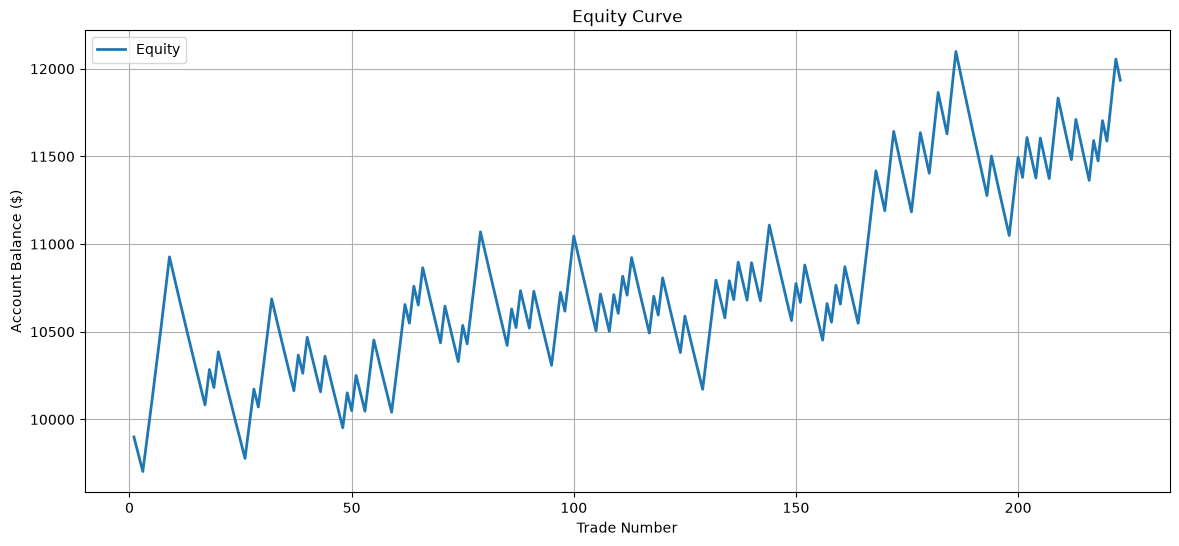

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    trades_df["trade_id"],
    trades_df["equity"],
    linewidth=2,
    label="Equity"
)

plt.title("Equity Curve")

plt.xlabel("Trade Number")

plt.ylabel("Account Balance ($)")

plt.grid(True)

plt.legend()

plt.show()

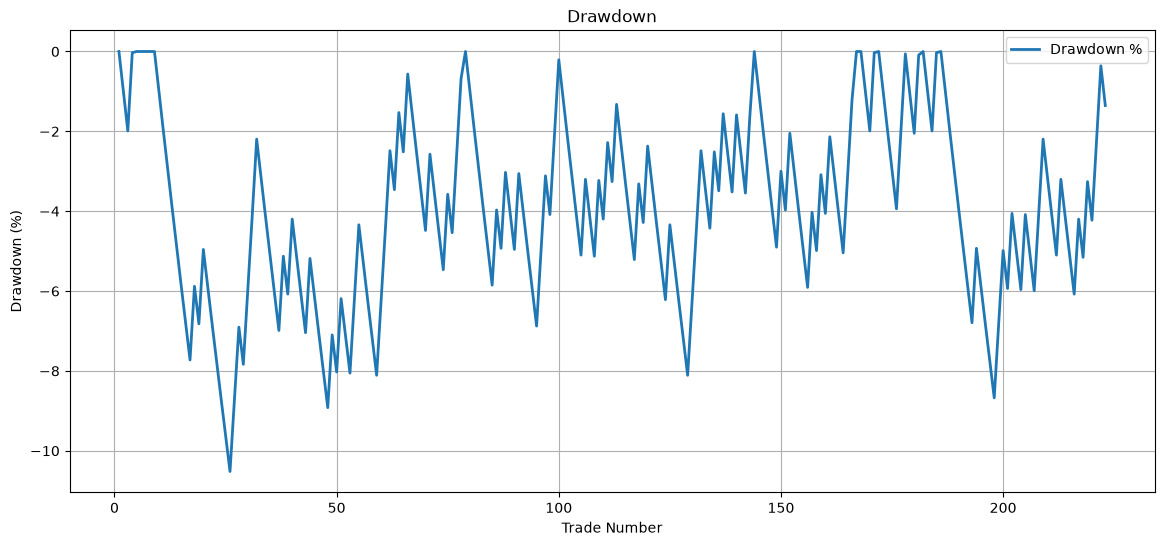

In [80]:
plt.figure(figsize=(14,6))

plt.plot(
    trades_df["trade_id"],
    trades_df["drawdown_pct"],
    linewidth=2,
    label="Drawdown %"
)

plt.title("Drawdown")

plt.xlabel("Trade Number")

plt.ylabel("Drawdown (%)")

plt.grid(True)

plt.legend()

plt.show()

In [82]:
# =============================================================================
# SECTION 9 — TRADE ANALYTICS DASHBOARD
# =============================================================================

In [88]:

# ============================================================
# HOLDING TIME
# ============================================================

trades_df["holding_hours"] = (
    trades_df["exit_time"]
    - trades_df["entry_time_utc"]
).dt.total_seconds() / 3600

trades_df["holding_days"] = (
    trades_df["holding_hours"] / 24
)

In [89]:
trades_df[[
    "trade_id",
    "entry_time_utc",
    "exit_time",
    "holding_hours",
    "holding_days"
]].head()

,trade_id,entry_time_utc,exit_time,holding_hours,holding_days
0,1,2025-02-21 08:00:00+00:00,2025-02-24 01:00:00+00:00,65.0,2.708333
1,2,2025-02-24 14:00:00+00:00,2025-02-25 11:00:00+00:00,21.0,0.875000
2,3,2025-02-25 11:00:00+00:00,2025-02-27 13:00:00+00:00,50.0,2.083333
3,4,2025-02-26 12:00:00+00:00,2025-02-28 18:00:00+00:00,54.0,2.250000
4,5,2025-02-27 08:00:00+00:00,2025-02-28 02:00:00+00:00,18.0,0.750000


In [90]:
# ============================================================
# HOLDING TIME SUMMARY
# ============================================================

print("=" * 55)
print("HOLDING TIME SUMMARY")
print("=" * 55)

print(f"Average Holding Time : {trades_df['holding_hours'].mean():.2f} Hours")

print(f"Median Holding Time  : {trades_df['holding_hours'].median():.2f} Hours")

print(f"Maximum Holding Time : {trades_df['holding_hours'].max():.2f} Hours")

print(f"Minimum Holding Time : {trades_df['holding_hours'].min():.2f} Hours")

print("=" * 55)

HOLDING TIME SUMMARY
Average Holding Time : 95.05 Hours
Median Holding Time  : 51.50 Hours
Maximum Holding Time : 816.00 Hours
Minimum Holding Time : 1.00 Hours


In [91]:
# ============================================================
# MONTHLY PERFORMANCE
# ============================================================

trades_df["trade_month"] = (
    trades_df["entry_time_utc"]
    .dt.to_period("M")
    .astype(str)
)

monthly_summary = (
    trades_df
    .groupby("trade_month")
    .agg(
        Trades=("trade_id", "count"),
        Wins=("result", lambda x: (x == "WIN").sum()),
        Losses=("result", lambda x: (x == "LOSS").sum()),
        Win_Rate=("result", lambda x: (x == "WIN").mean() * 100),
        Gross_Profit=("pnl", lambda x: x[x > 0].sum()),
        Gross_Loss=("pnl", lambda x: abs(x[x < 0].sum())),
        Net_Profit=("pnl", "sum"),
        Average_PnL=("pnl", "mean"),
        Ending_Balance=("balance_after", "last")
    )
    .reset_index()
)

monthly_summary

C:\Users\sc09511\AppData\Local\Temp\ipykernel_8164\4033478542.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


,trade_month,Trades,Wins,Losses,Win_Rate,Gross_Profit,Gross_Loss,Net_Profit,Average_PnL,Ending_Balance
0,2025-02,5,2,3,40.000000,392.00,297.01,94.99,18.998,10094.99
1,2025-03,20,6,14,30.000000,1237.46,1456.04,-218.58,-10.929,9876.42
2,2025-04,19,8,11,42.105263,1623.12,1138.86,484.26,25.487368,10360.68
3,2025-05,19,7,12,36.842105,1420.54,1232.20,188.34,9.912632,10549.01
4,2025-06,20,7,13,35.000000,1477.84,1393.49,84.35,4.2175,10633.36
5,2025-07,19,7,12,36.842105,1474.75,1281.43,193.32,10.174737,10826.65
6,2025-08,19,6,13,31.578947,1268.18,1395.59,-127.41,-6.705789,10699.23
7,2025-09,18,6,12,33.333333,1255.50,1274.58,-19.08,-1.06,10680.12
8,2025-10,22,8,14,36.363636,1702.87,1511.97,190.9,8.677273,10871.01
9,2025-11,19,8,11,42.105263,1773.43,1240.41,533.02,28.053684,11404.04


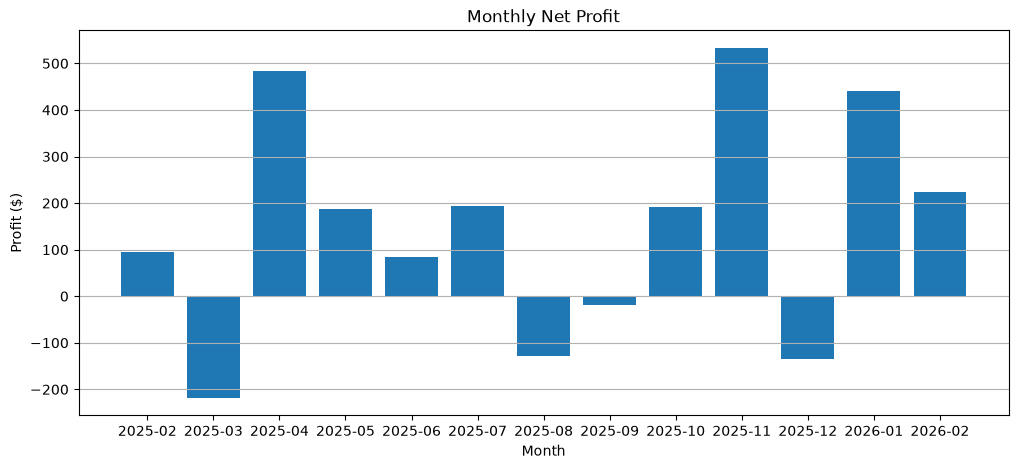

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.bar(
    monthly_summary["trade_month"],
    monthly_summary["Net_Profit"]
)

plt.title("Monthly Net Profit")

plt.xlabel("Month")

plt.ylabel("Profit ($)")

plt.grid(axis="y")

plt.show()

In [93]:
# ============================================================
# LONG vs SHORT PERFORMANCE
# ============================================================

direction_summary = (
    trades_df
    .groupby("trade_type")
    .agg(
        Trades=("trade_id", "count"),
        Wins=("result", lambda x: (x == "WIN").sum()),
        Losses=("result", lambda x: (x == "LOSS").sum()),
        Win_Rate=("result", lambda x: (x == "WIN").mean() * 100),
        Net_Profit=("pnl", "sum"),
        Average_PnL=("pnl", "mean"),
        Average_Holding_Hours=("holding_hours", "mean")
    )
    .reset_index()
)

direction_summary

,trade_type,Trades,Wins,Losses,Win_Rate,Net_Profit,Average_PnL,Average_Holding_Hours
0,BUY,110,45,65,40.909091,2599.37,23.630636,102.600
1,SELL,113,36,76,31.858407,-664.57,-5.88115,87.625


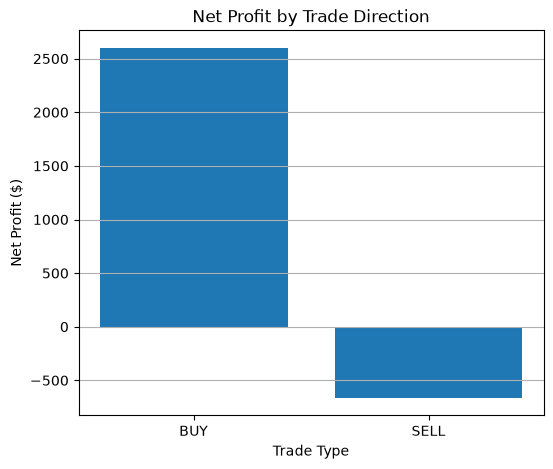

In [94]:
plt.figure(figsize=(6,5))

plt.bar(
    direction_summary["trade_type"],
    direction_summary["Net_Profit"]
)

plt.title("Net Profit by Trade Direction")

plt.xlabel("Trade Type")

plt.ylabel("Net Profit ($)")

plt.grid(axis="y")

plt.show()

In [95]:
# ============================================================
# WINNING & LOSING STREAKS
# ============================================================

current_win = 0
current_loss = 0

max_win_streak = 0
max_loss_streak = 0

for result in trades_df["result"]:

    if result == "WIN":

        current_win += 1
        current_loss = 0

    else:

        current_loss += 1
        current_win = 0

    max_win_streak = max(max_win_streak, current_win)
    max_loss_streak = max(max_loss_streak, current_loss)

print("="*55)
print("STREAK ANALYSIS")
print("="*55)

print(f"Longest Winning Streak : {max_win_streak}")

print(f"Longest Losing Streak  : {max_loss_streak}")

print("="*55)

STREAK ANALYSIS
Longest Winning Streak : 6
Longest Losing Streak  : 8


In [96]:
# =============================================================================
# PROJECT CHECKPOINT
# =============================================================================
#
# PROJECT: EUR/USD ASIAN SESSION BREAKOUT RESEARCH FRAMEWORK
#
# STATUS
# ------
# The core backtesting engine has now been completed.
#
# The framework is capable of:
#
#   ✓ Loading and validating historical market data
#   ✓ Timezone standardization (UTC as canonical timezone)
#   ✓ Session identification
#   ✓ Asian High / Low calculation
#   ✓ London breakout signal generation
#   ✓ Trade construction
#   ✓ Event-driven trade simulation
#   ✓ Dynamic portfolio accounting
#   ✓ Performance analytics
#   ✓ Equity curve generation
#   ✓ Drawdown analysis
#   ✓ Trade analytics
#
# =============================================================================
# COMPLETED MODULES
# =============================================================================
#
# SECTION 1
# ----------
# Import Libraries
#
# SECTION 2
# ----------
# Load Historical Market Data
#
# SECTION 3
# ----------
# Configuration & Strategy Parameters
#
# SECTION 4
# ----------
# Feature Engineering
# • Session Flags
# • Asian Session High
# • Asian Session Low
# • Asian Session Range
#
# SECTION 5
# ----------
# Strategy Implementation
# • Breakout Detection
# • BUY Signals
# • SELL Signals
# • First Trade Per Day
#
# SECTION 6
# ----------
# Trade Construction
# • Entry Price
# • Stop Loss
# • Take Profit
# • Trade Risk
# • Trade Log
#
# SECTION 7
# ----------
# Trade Simulation Engine
# • Candle-by-Candle Simulation
# • Stop Loss Detection
# • Take Profit Detection
# • Same Candle Handling
# • Trade Exit Recording
#
# SECTION 8
# ----------
# Portfolio Accounting
# • Dynamic Position Sizing
# • Risk Amount
# • Profit & Loss
# • Balance Tracking
# • R-Multiple
# • Pip Profit/Loss
#
# SECTION 9
# ----------
# Performance Analytics
# • Total Trades
# • Win Rate
# • Profit Factor
# • Expectancy
# • Net Profit
# • Return %
#
# SECTION 10
# -----------
# Equity Curve & Drawdown Analysis
# • Running Equity
# • Peak Equity
# • Dollar Drawdown
# • Percentage Drawdown
# • Maximum Drawdown
#
# SECTION 11
# -----------
# Trade Analytics
# • Holding Time
# • Monthly Performance
# • Long vs Short Analysis
# • Winning Streaks
# • Losing Streaks
#
# =============================================================================
# CURRENT ARCHITECTURE
# =============================================================================
#
# Historical Market Data
#           │
#           ▼
# Data Engineering
#           │
#           ▼
# Feature Engineering
#           │
#           ▼
# Strategy Rules
#           │
#           ▼
# Trade Construction
#           │
#           ▼
# Trade Simulation Engine
#           │
#           ▼
# Portfolio Accounting
#           │
#           ▼
# Performance Analytics
#           │
#           ▼
# Equity & Drawdown Analysis
#           │
#           ▼
# Trade Analytics
#
# =============================================================================
# NEXT DEVELOPMENT PHASE
# =============================================================================
#
# SECTION 12
# ----------
# Visual Analytics Dashboard
#
# Planned Components:
#
# • Equity Curve Dashboard
# • Drawdown Dashboard
# • Monthly Performance Charts
# • Win/Loss Distribution
# • Trade P&L Distribution
# • Holding Time Distribution
# • BUY vs SELL Comparison
#
# Followed By:
#
# • Parameter Optimization
# • Walk-Forward Testing
# • Monte Carlo Analysis
# • Strategy Benchmarking
# • Reinforcement Learning Comparison
#
# =============================================================================

In [97]:
import matplotlib.pyplot as plt

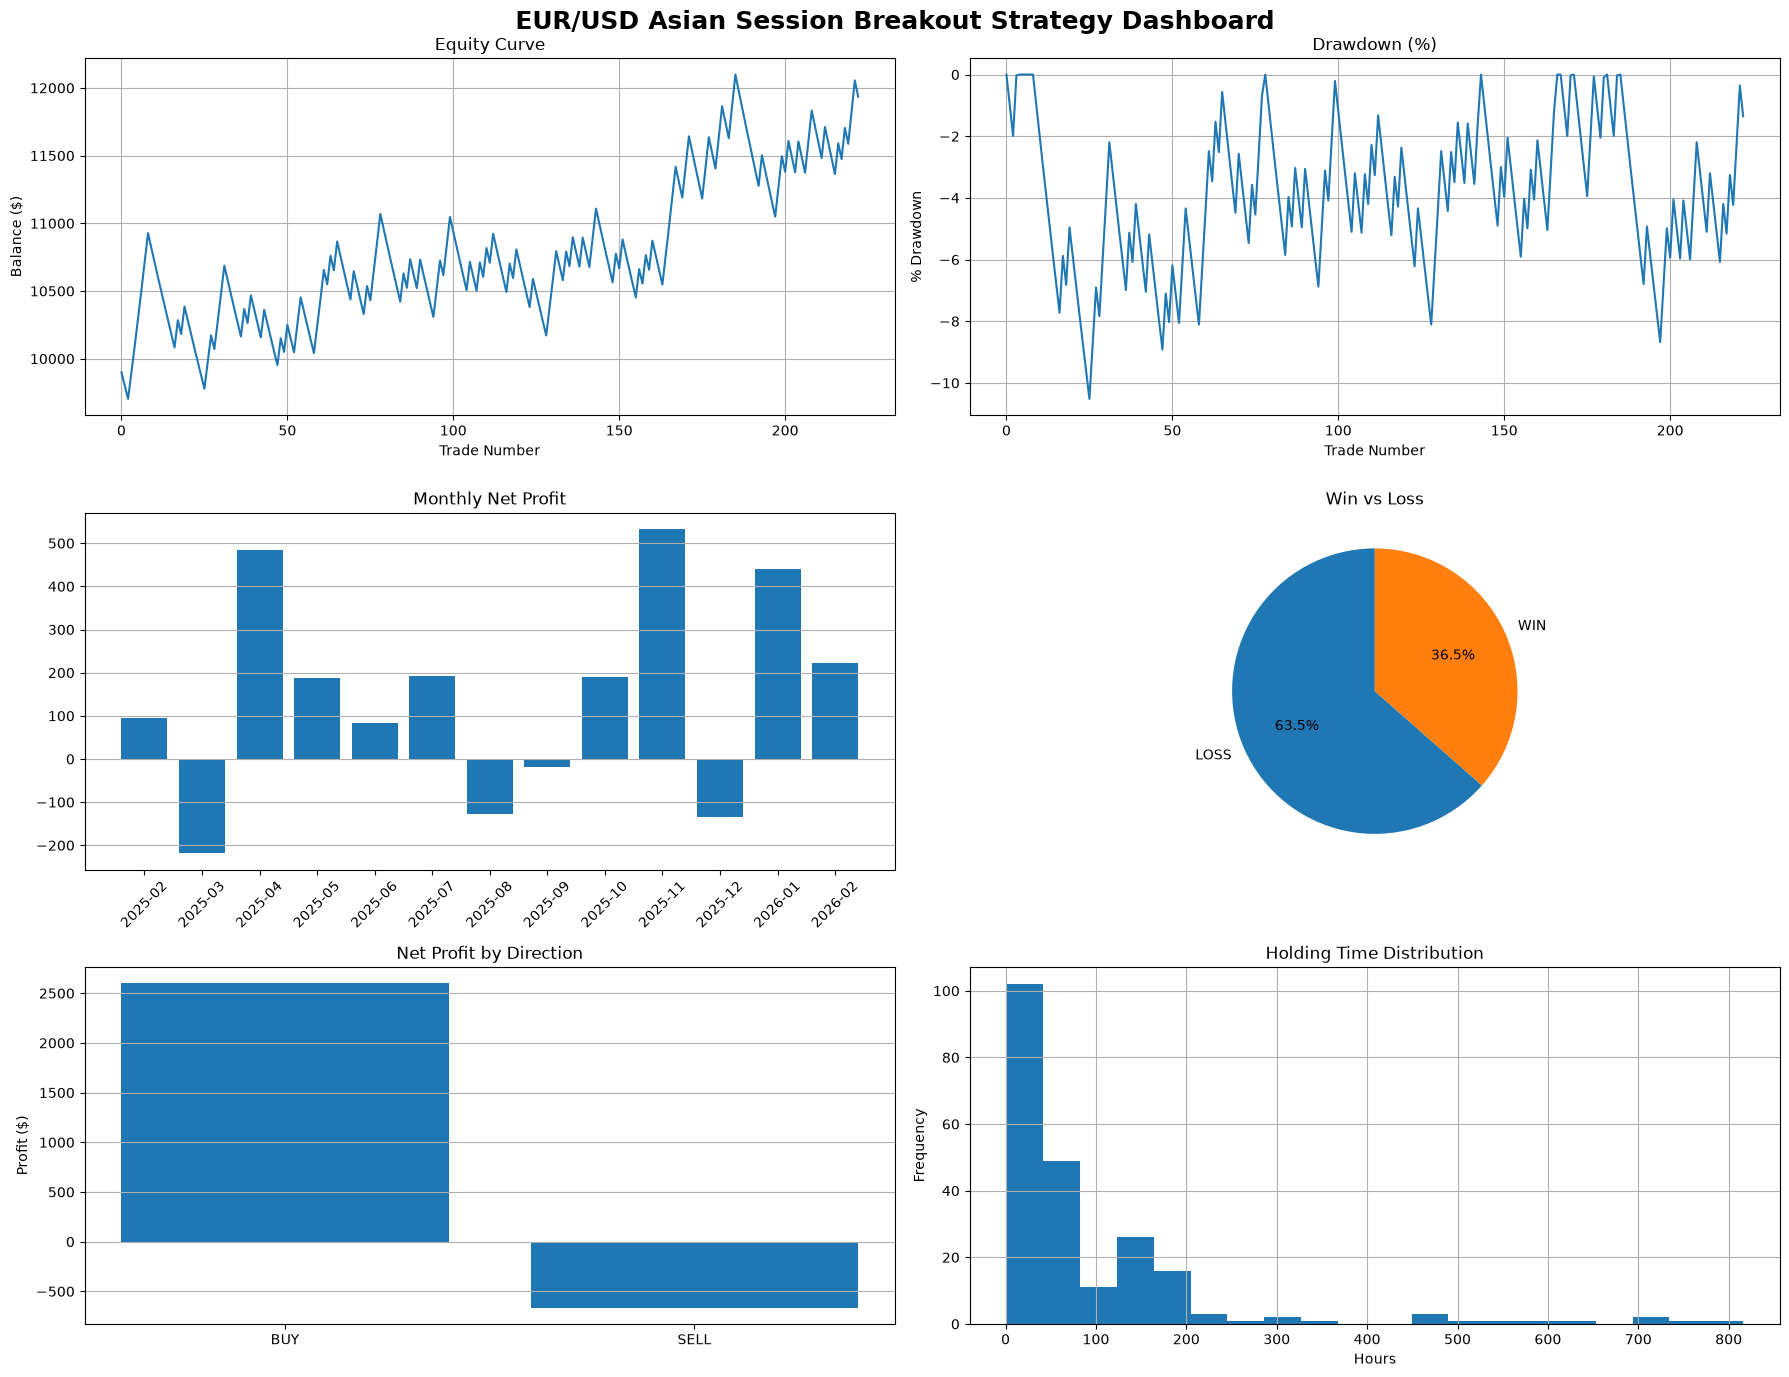

In [98]:
# ============================================================
# VISUAL ANALYTICS DASHBOARD
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# ------------------------------------------------------------
# Chart 1 - Equity Curve
# ------------------------------------------------------------

axes[0,0].plot(trades_df["balance_after"])

axes[0,0].set_title("Equity Curve")

axes[0,0].set_xlabel("Trade Number")

axes[0,0].set_ylabel("Balance ($)")

axes[0,0].grid(True)

# ------------------------------------------------------------
# Chart 2 - Drawdown
# ------------------------------------------------------------

axes[0,1].plot(trades_df["drawdown_pct"])

axes[0,1].set_title("Drawdown (%)")

axes[0,1].set_xlabel("Trade Number")

axes[0,1].set_ylabel("% Drawdown")

axes[0,1].grid(True)

# ------------------------------------------------------------
# Chart 3 - Monthly Profit
# ------------------------------------------------------------

axes[1,0].bar(
    monthly_summary["trade_month"],
    monthly_summary["Net_Profit"]
)

axes[1,0].set_title("Monthly Net Profit")

axes[1,0].tick_params(axis="x", rotation=45)

axes[1,0].grid(axis="y")

# ------------------------------------------------------------
# Chart 4 - Win / Loss Distribution
# ------------------------------------------------------------

win_loss = trades_df["result"].value_counts()

axes[1,1].pie(
    win_loss,
    labels=win_loss.index,
    autopct="%1.1f%%",
    startangle=90
)

axes[1,1].set_title("Win vs Loss")

# ------------------------------------------------------------
# Chart 5 - Buy vs Sell Profit
# ------------------------------------------------------------

axes[2,0].bar(
    direction_summary["trade_type"],
    direction_summary["Net_Profit"]
)

axes[2,0].set_title("Net Profit by Direction")

axes[2,0].set_ylabel("Profit ($)")

axes[2,0].grid(axis="y")

# ------------------------------------------------------------
# Chart 6 - Holding Time Distribution
# ------------------------------------------------------------

axes[2,1].hist(
    trades_df["holding_hours"],
    bins=20
)

axes[2,1].set_title("Holding Time Distribution")

axes[2,1].set_xlabel("Hours")

axes[2,1].set_ylabel("Frequency")

axes[2,1].grid(True)

# ------------------------------------------------------------
# Dashboard Formatting
# ------------------------------------------------------------

plt.suptitle(
    "EUR/USD Asian Session Breakout Strategy Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [99]:
# =============================================================================
# SECTION 12.1 — DASHBOARD KPI DATASET
# =============================================================================
#
# PURPOSE
# -------
# Consolidate the most important performance metrics into a single
# dictionary for use throughout the dashboard.
#
# This serves as the single source of truth for KPI cards and reports.
#
# =============================================================================

dashboard_kpis = {

    # ---------------------------------------------------------
    # Portfolio
    # ---------------------------------------------------------

    "Starting Balance": BACKTEST["starting_balance"],

    "Ending Balance": ending_balance,

    "Net Profit": net_profit,

    "Return (%)": return_percent,

    # ---------------------------------------------------------
    # Trading Statistics
    # ---------------------------------------------------------

    "Total Trades": total_trades,

    "Winning Trades": winning_trades,

    "Losing Trades": losing_trades,

    "Win Rate (%)": win_rate,

    # ---------------------------------------------------------
    # Risk Metrics
    # ---------------------------------------------------------

    "Profit Factor": profit_factor,

    "Expectancy": expectancy,

    "Max Drawdown ($)": max_drawdown,

    "Max Drawdown (%)": max_drawdown_pct,

    # ---------------------------------------------------------
    # Trade Statistics
    # ---------------------------------------------------------

    "Average Holding Hours": trades_df["holding_hours"].mean(),

    "Average Win ($)": average_win,

    "Average Loss ($)": average_loss,

    "Largest Win ($)": largest_win,

    "Largest Loss ($)": largest_loss,

    "Average R-Multiple": trades_df["r_multiple"].mean(),

    "Longest Win Streak": max_win_streak,

    "Longest Loss Streak": max_loss_streak

}

In [100]:
kpi_df = (
    pd.DataFrame(
        dashboard_kpis.items(),
        columns=["Metric", "Value"]
    )
)

kpi_df

,Metric,Value
0,Starting Balance,10000.000000
1,Ending Balance,11934.700000
2,Net Profit,1934.800000
3,Return (%),19.347000
4,Total Trades,223.000000
5,Winning Trades,81.000000
6,Losing Trades,141.000000
7,Win Rate (%),36.322870
8,Profit Factor,1.125943
9,Expectancy,8.676233


In [106]:
!pip install plotly


In [108]:
import sys

print(sys.executable)
print(sys.version)

C:\Users\sc09511\rl_env\Scripts\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [109]:
import sys

!{sys.executable} -m pip install plotly

  Using cached plotly-6.9.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
Using cached plotly-6.9.0-py3-none-any.whl (9.9 MB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   ----

In [110]:
# =============================================================================
# IMPORTS
# =============================================================================

import plotly.graph_objects as go
import plotly.express as px

from plotly.subplots import make_subplots

import plotly.io as pio

# =============================================================================
# DASHBOARD THEME
# =============================================================================

pio.templates.default = "plotly_white"

# =============================================================================
# COLOUR PALETTE
# =============================================================================

COLORS = {

    "primary": "#2563EB",      # Blue
    "secondary": "#10B981",    # Green
    "danger": "#EF4444",       # Red
    "warning": "#F59E0B",      # Orange
    "dark": "#111827",
    "light": "#F3F4F6"

}

# =============================================================================
# DEFAULT LAYOUT
# =============================================================================

DEFAULT_LAYOUT = dict(

    font=dict(

        family="Segoe UI",
        size=13

    ),

    title_font=dict(

        size=22

    ),

    hovermode="x unified",

    plot_bgcolor="white",

    paper_bgcolor="white",

    margin=dict(

        l=50,
        r=30,
        t=70,
        b=50

    )

)

In [113]:
import plotly
import plotly.graph_objects as go
import plotly.express as px

print("Plotly Version:", plotly.__version__)

Plotly Version: 6.9.0


In [114]:
# =============================================================================
# SECTION 12.3 - KPI DASHBOARD
# =============================================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# -----------------------------------------------------------------------------
# CREATE KPI GRID
# -----------------------------------------------------------------------------

fig = make_subplots(

    rows=2,
    cols=5,

    specs=[
        [{"type":"indicator"}]*5,
        [{"type":"indicator"}]*5
    ],

    horizontal_spacing=0.06,
    vertical_spacing=0.22

)

# -----------------------------------------------------------------------------
# KPI DEFINITIONS
# -----------------------------------------------------------------------------

kpis = [

    ("Starting Balance", f"${dashboard_kpis['Starting Balance']:,.2f}"),
    ("Ending Balance", f"${dashboard_kpis['Ending Balance']:,.2f}"),
    ("Net Profit", f"${dashboard_kpis['Net Profit']:,.2f}"),
    ("Return", f"{dashboard_kpis['Return (%)']:.2f}%"),
    ("Win Rate", f"{dashboard_kpis['Win Rate (%)']:.2f}%"),

    ("Profit Factor", f"{dashboard_kpis['Profit Factor']:.2f}"),
    ("Max Drawdown", f"{dashboard_kpis['Max Drawdown (%)']:.2f}%"),
    ("Expectancy", f"{dashboard_kpis['Expectancy']:.2f}"),
    ("Average R", f"{dashboard_kpis['Average R-Multiple']:.2f}"),
    ("Trades", f"{dashboard_kpis['Total Trades']}")

]

# -----------------------------------------------------------------------------
# ADD KPI CARDS
# -----------------------------------------------------------------------------

index = 0

for r in range(1,3):

    for c in range(1,6):

        label, value = kpis[index]

        fig.add_trace(

            go.Indicator(

                mode="number",

                value=0,

                number={

                    "prefix":"",
                    "suffix":"",
                    "font":{"size":28}

                },

                title={

                    "text":f"<b>{label}</b><br><span style='font-size:24px'>{value}</span>"

                }

            ),

            row=r,
            col=c

        )

        index += 1

# -----------------------------------------------------------------------------
# LAYOUT
# -----------------------------------------------------------------------------

fig.update_layout(

    template="plotly_white",

    height=420,

    title={

        "text":"EUR/USD Strategy KPI Dashboard",
        "x":0.5

    },

    margin=dict(

        t=70,
        l=20,
        r=20,
        b=20

    )

)

fig.show()


In [115]:
import plotly.io as pio

pio.renderers.default = "notebook_connected"

print("Renderer:", pio.renderers.default)

Renderer: notebook_connected


In [116]:
import plotly.io as pio

pio.renderers.default = "browser"

In [117]:
# =============================================================================
# SECTION 12 - VISUAL ANALYTICS ENGINE
# =============================================================================

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio

pio.renderers.default = "notebook_connected"


class StrategyDashboard:

    """
    Interactive Dashboard
    """

    def __init__(

        self,

        trades_df,

        monthly_summary,

        direction_summary,

        dashboard_kpis

    ):

        self.trades = trades_df

        self.monthly = monthly_summary

        self.direction = direction_summary

        self.kpis = dashboard_kpis

        self.theme = "plotly_white"

In [118]:
class StrategyDashboard(StrategyDashboard):

    def plot_equity_curve(self):

        fig = go.Figure()

        fig.add_trace(

            go.Scatter(

                x=self.trades["trade_id"],

                y=self.trades["balance_after"],

                mode="lines+markers",

                name="Equity",

                customdata=self.trades[[

                    "entry_time_utc",

                    "pnl",

                    "r_multiple",

                    "result"

                ]],

                hovertemplate=

                "<b>Trade %{x}</b><br>" +

                "Balance: $%{y:,.2f}<br>" +

                "Entry: %{customdata[0]}<br>" +

                "PnL: $%{customdata[1]:,.2f}<br>" +

                "R Multiple: %{customdata[2]:.2f}<br>" +

                "Result: %{customdata[3]}" +

                "<extra></extra>"

            )

        )

        fig.update_layout(

            template=self.theme,

            title="Equity Curve",

            xaxis_title="Trade",

            yaxis_title="Account Balance ($)",

            hovermode="x unified",

            height=600

        )

        fig.show()

In [119]:
dashboard = StrategyDashboard(

    trades_df,

    monthly_summary,

    direction_summary,

    dashboard_kpis

)

dashboard.plot_equity_curve()

In [120]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=[1,2,3,4],
        y=[10,15,13,20],
        mode="lines+markers"
    )
)

fig.show()

In [121]:
print(trades_df.columns.tolist())

['trade_id', 'entry_time_utc', 'entry_time_london', 'trade_type', 'entry_price', 'stop_loss', 'take_profit', 'risk', 'exit_time', 'exit_price', 'exit_reason', 'result', 'pnl', 'pnl_pips', 'balance_before', 'balance_after', 'entry_index', 'risk_amount', 'r_multiple', 'equity', 'equity_peak', 'drawdown', 'drawdown_pct', 'holding_hours', 'holding_days', 'trade_month']


In [122]:
print(monthly_summary.columns.tolist())

['trade_month', 'Trades', 'Wins', 'Losses', 'Win_Rate', 'Gross_Profit', 'Gross_Loss', 'Net_Profit', 'Average_PnL', 'Ending_Balance']


In [123]:
print(direction_summary.columns.tolist())

['trade_type', 'Trades', 'Wins', 'Losses', 'Win_Rate', 'Net_Profit', 'Average_PnL', 'Average_Holding_Hours']


In [125]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=trades_df["trade_id"],
        y=trades_df["balance_after"],
        mode="lines+markers",
        name="Account Balance",
        line=dict(width=3),
        marker=dict(size=7),

        customdata=trades_df[
            [
                "entry_time_london",
                "trade_type",
                "result",
                "pnl",
                "r_multiple",
                "holding_hours"
            ]
        ],

        hovertemplate=(
            "<b>Trade #%{x}</b><br>"
            "Balance: $%{y:,.2f}<br>"
            "Entry: %{customdata[0]}<br>"
            "Direction: %{customdata[1]}<br>"
            "Result: %{customdata[2]}<br>"
            "PnL: $%{customdata[3]:,.2f}<br>"
            "R Multiple: %{customdata[4]:.2f}<br>"
            "Holding Time: %{customdata[5]:.2f} hrs"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title="Equity Curve",
    template="plotly_white",
    xaxis_title="Trade Number",
    yaxis_title="Account Balance ($)",
    hovermode="closest",
    height=600
)

fig.show()

In [126]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(

    go.Scatter(

        x=trades_df["trade_id"],

        y=trades_df["drawdown_pct"],

        mode="lines",

        fill="tozeroy",

        name="Drawdown",

        line=dict(width=2, color="firebrick"),

        customdata=trades_df[
            [
                "entry_time_london",
                "drawdown",
                "balance_after"
            ]
        ],

        hovertemplate=(

            "<b>Trade #%{x}</b><br>"
            "Date: %{customdata[0]}<br>"
            "Drawdown: %{y:.2f}%<br>"
            "Drawdown ($): $%{customdata[1]:,.2f}<br>"
            "Balance: $%{customdata[2]:,.2f}"
            "<extra></extra>"

        )

    )

)

fig.update_layout(

    title="Drawdown Curve",

    template="plotly_white",

    xaxis_title="Trade Number",

    yaxis_title="Drawdown (%)",

    hovermode="closest",

    height=500

)

fig.update_yaxes(autorange="reversed")

fig.show()

In [127]:
import plotly.graph_objects as go

# ----------------------------------------------------------
# Assign colours based on profit/loss
# ----------------------------------------------------------

colors = [
    "green" if profit >= 0 else "red"
    for profit in monthly_summary["Net_Profit"]
]

# ----------------------------------------------------------
# Create chart
# ----------------------------------------------------------

fig = go.Figure()

fig.add_trace(

    go.Bar(

        x=monthly_summary["trade_month"],

        y=monthly_summary["Net_Profit"],

        marker_color=colors,

        customdata=monthly_summary[
            [
                "Trades",
                "Wins",
                "Losses",
                "Win_Rate",
                "Ending_Balance"
            ]
        ],

        hovertemplate=(

            "<b>%{x}</b><br>"
            "Net Profit: $%{y:,.2f}<br>"
            "Trades: %{customdata[0]}<br>"
            "Wins: %{customdata[1]}<br>"
            "Losses: %{customdata[2]}<br>"
            "Win Rate: %{customdata[3]:.2f}%<br>"
            "Ending Balance: $%{customdata[4]:,.2f}"
            "<extra></extra>"

        )

    )

)

# ----------------------------------------------------------
# Add zero reference line
# ----------------------------------------------------------

fig.add_hline(
    y=0,
    line_dash="dash",
    line_color="black"
)

# ----------------------------------------------------------
# Layout
# ----------------------------------------------------------

fig.update_layout(

    title="Monthly Performance",

    template="plotly_white",

    xaxis_title="Month",

    yaxis_title="Net Profit ($)",

    height=550

)

fig.show()

In [129]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(

    go.Histogram(

        x=trades_df["pnl"],

        nbinsx=30,

        name="PnL Distribution",

        hovertemplate=(

            "PnL Range: $%{x:,.2f}<br>"
            "Trades: %{y}"
            "<extra></extra>"

        )

    )

)

# ----------------------------------------------------------
# Add breakeven reference line
# ----------------------------------------------------------

fig.add_vline(

    x=0,

    line_dash="dash",

    line_color="red",

    annotation_text="Break-even"

)

# ----------------------------------------------------------
# Layout
# ----------------------------------------------------------

fig.update_layout(

    title="Trade PnL Distribution",

    template="plotly_white",

    xaxis_title="PnL ($)",

    yaxis_title="Number of Trades",

    bargap=0.05,

    height=550

)

fig.show()

In [130]:
import plotly.graph_objects as go

# ----------------------------------------------------------
# Split winners and losers
# ----------------------------------------------------------

winners = trades_df[trades_df["result"] == "WIN"]

losers = trades_df[trades_df["result"] == "LOSS"]

fig = go.Figure()

# ----------------------------------------------------------
# Winners
# ----------------------------------------------------------

fig.add_trace(

    go.Histogram(

        x=winners["holding_hours"],

        name="Winning Trades",

        opacity=0.75,

        nbinsx=25,

        hovertemplate=(

            "Holding Time: %{x:.2f} hrs<br>"
            "Winning Trades: %{y}"
            "<extra></extra>"

        )

    )

)

# ----------------------------------------------------------
# Losers
# ----------------------------------------------------------

fig.add_trace(

    go.Histogram(

        x=losers["holding_hours"],

        name="Losing Trades",

        opacity=0.75,

        nbinsx=25,

        hovertemplate=(

            "Holding Time: %{x:.2f} hrs<br>"
            "Losing Trades: %{y}"
            "<extra></extra>"

        )

    )

)

# ----------------------------------------------------------
# Layout
# ----------------------------------------------------------

fig.update_layout(

    title="Holding Time Distribution",

    template="plotly_white",

    xaxis_title="Holding Time (Hours)",

    yaxis_title="Trade Count",

    barmode="overlay",

    height=550

)

fig.show()

In [131]:
import plotly.graph_objects as go

fig = go.Figure()

# ----------------------------------------------------------
# Net Profit
# ----------------------------------------------------------

fig.add_trace(

    go.Bar(

        x=direction_summary["trade_type"],

        y=direction_summary["Net_Profit"],

        name="Net Profit",

        customdata=direction_summary[
            [
                "Trades",
                "Wins",
                "Losses",
                "Win_Rate",
                "Average_PnL",
                "Average_Holding_Hours"
            ]
        ],

        hovertemplate=(

            "<b>%{x}</b><br>"
            "Net Profit: $%{y:,.2f}<br><br>"

            "Trades: %{customdata[0]}<br>"
            "Wins: %{customdata[1]}<br>"
            "Losses: %{customdata[2]}<br>"
            "Win Rate: %{customdata[3]:.2f}%<br>"
            "Average PnL: $%{customdata[4]:,.2f}<br>"
            "Average Hold: %{customdata[5]:.2f} hrs"

            "<extra></extra>"

        )

    )

)

fig.update_layout(

    title="Buy vs Sell Performance",

    template="plotly_white",

    xaxis_title="Trade Direction",

    yaxis_title="Net Profit ($)",

    height=550

)

fig.show()

In [132]:
dashboard_kpis

{'Starting Balance': 10000,
 'Ending Balance': 11934.7,
 'Net Profit': 1934.7999999999995,
 'Return (%)': 19.34700000000001,
 'Total Trades': 223,
 'Winning Trades': np.int64(81),
 'Losing Trades': np.int64(141),
 'Win Rate (%)': np.float64(36.32286995515695),
 'Profit Factor': 1.1259433710486475,
 'Expectancy': np.float64(8.6762331838565),
 'Max Drawdown ($)': -1149.4799999999996,
 'Max Drawdown (%)': -10.519495494704008,
 'Average Holding Hours': np.float64(95.04504504504504),
 'Average Win ($)': np.float64(213.5464197530865),
 'Average Loss ($)': np.float64(-108.18633802816902),
 'Largest Win ($)': 237.22,
 'Largest Loss ($)': -120.98,
 'Average R-Multiple': np.float64(0.08968609865470852),
 'Longest Win Streak': 6,
 'Longest Loss Streak': 8}

In [133]:
import plotly.graph_objects as go

fig = go.Figure()

kpis = [

    ("Balance", f"${dashboard_kpis['Ending Balance']:,.0f}"),
    ("Return", f"{dashboard_kpis['Return (%)']:.2f}%"),
    ("Win Rate", f"{dashboard_kpis['Win Rate (%)']:.1f}%"),
    ("Profit Factor", f"{dashboard_kpis['Profit Factor']:.2f}"),
    ("Max DD", f"{dashboard_kpis['Max Drawdown (%)']:.2f}%"),
    ("Trades", str(dashboard_kpis["Total Trades"])),
    ("Avg R", f"{dashboard_kpis['Average R-Multiple']:.2f}"),
    ("Expectancy", f"${dashboard_kpis['Expectancy']:.2f}")

]

for i, (title, value) in enumerate(kpis):

    x0 = i / 8
    x1 = (i + 1) / 8

    fig.add_shape(
        type="rect",
        xref="paper",
        yref="paper",
        x0=x0 + 0.005,
        x1=x1 - 0.005,
        y0=0.15,
        y1=0.95,
        line=dict(color="lightgray"),
        fillcolor="white"
    )

    fig.add_annotation(
        x=(x0 + x1) / 2,
        y=0.72,
        xref="paper",
        yref="paper",
        text=f"<b>{title}</b>",
        showarrow=False,
        font=dict(size=14)
    )

    fig.add_annotation(
        x=(x0 + x1) / 2,
        y=0.38,
        xref="paper",
        yref="paper",
        text=f"<span style='font-size:22px'><b>{value}</b></span>",
        showarrow=False
    )

fig.update_layout(

    title="EUR/USD Strategy Dashboard",

    template="plotly_white",

    height=180,

    margin=dict(t=50, l=20, r=20, b=20),

    xaxis=dict(visible=False),

    yaxis=dict(visible=False)

)

fig.show()

In [136]:
# =============================================================================
# SECTION 13 - EXPORT RESULTS
# =============================================================================

import os
import json

# -----------------------------------------------------------------------------
# Create output folder
# -----------------------------------------------------------------------------

OUTPUT_FOLDER = "outputs"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# -----------------------------------------------------------------------------
# Export DataFrames
# -----------------------------------------------------------------------------

trades_df.to_csv(
    f"{OUTPUT_FOLDER}/trades.csv",
    index=False
)

monthly_summary.to_csv(
    f"{OUTPUT_FOLDER}/monthly_summary.csv",
    index=False
)

direction_summary.to_csv(
    f"{OUTPUT_FOLDER}/direction_summary.csv",
    index=False
)

# -----------------------------------------------------------------------------
# Convert NumPy values to Python types
# -----------------------------------------------------------------------------

dashboard_export = {}

for key, value in dashboard_kpis.items():

    if hasattr(value, "item"):
        dashboard_export[key] = value.item()
    else:
        dashboard_export[key] = value

# -----------------------------------------------------------------------------
# Export KPIs
# -----------------------------------------------------------------------------

with open(f"{OUTPUT_FOLDER}/dashboard_kpis.json", "w") as file:

    json.dump(
        dashboard_export,
        file,
        indent=4
    )

print("Dashboard data exported successfully.")

Dashboard data exported successfully.


In [2]:
print(trades.columns.tolist())

NameError: name 'trades' is not defined

In [1]:
print(trades_df.columns.tolist())

NameError: name 'trades_df' is not defined

In [2]:
import pandas as pd

trades_df = pd.read_csv("../outputs/trades.csv")

print(trades_df.columns.tolist())

['trade_id', 'entry_time_utc', 'entry_time_london', 'trade_type', 'entry_price', 'stop_loss', 'take_profit', 'risk', 'exit_time', 'exit_price', 'exit_reason', 'result', 'pnl', 'pnl_pips', 'balance_before', 'balance_after', 'entry_index', 'risk_amount', 'r_multiple', 'equity', 'equity_peak', 'drawdown', 'drawdown_pct', 'holding_hours', 'holding_days', 'trade_month']
